# Acoustic cavity modes with pyCAFE — CHEXA8 validation

**Air-filled rigid-walled cavity, 0.414 × 0.314 × 0.360 m, meshed with
16 × 16 × 16 CHEXA8 acoustic elements.**

The CHEXA8 is an 8-node trilinear brick with one pressure DOF per node,
integrated with a 2×2×2 Gauss rule:

$$ K_e = \int_{V_e}\nabla N^{T}\nabla N\,dV, \qquad
   M_e = \frac{1}{c_0^{2}}\int_{V_e} N^{T}N\,dV,
   \qquad K\mathbf{p} = \omega^{2}M\mathbf{p} $$

For a rectangular cavity with rigid walls the exact solution is known:

$$ p_{lmn} = \cos\frac{l\pi x}{L_x}\cos\frac{m\pi y}{L_y}\cos\frac{n\pi z}{L_z},
   \qquad
   f_{lmn} = \frac{c_0}{2}\sqrt{\Bigl(\frac{l}{L_x}\Bigr)^{2}
   + \Bigl(\frac{m}{L_y}\Bigr)^{2} + \Bigl(\frac{n}{L_z}\Bigr)^{2}} $$

so the computed frequencies can be checked one by one against it.

---
## 1 — Model

The model is stated once, as a `ModelSpec`: which geometry, which fluid, and the
highest frequency of interest. `build_model` turns it into a Gmsh mesh, checks it
against the pyCAFE contract at that frequency, and assembles the acoustic system —
rigid walls need no boundary condition, they are the natural one.

The geometry is drawn first, coloured by the role of each physical group: `build_model` does it before assembling anything, because a wrong geometry is visible in the picture and in none of the numbers.

ModelSpec
  geometry     Library('box_cavity', Lx=0.414, Ly=0.314, Lz=0.36, nx=16, ny=16, nz=16)
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  f_max        1000.0 Hz (lambda = 343 mm)
  mesh size    34.3 mm (10 elements per wavelength)
  mesh file    box_cavity.msh


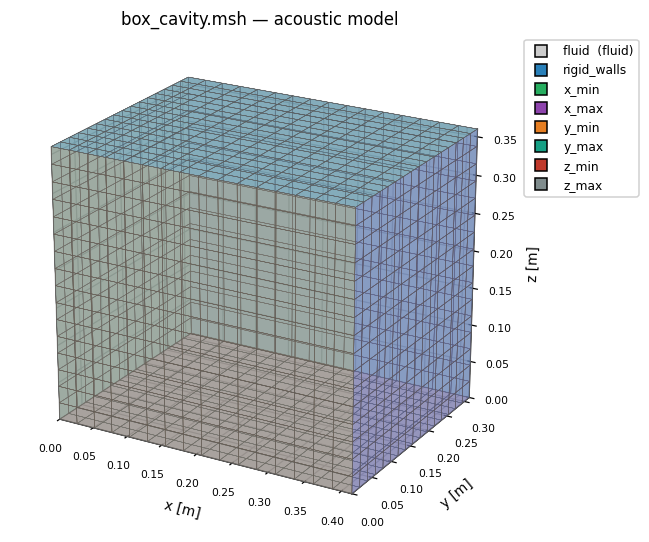

Acoustic domain from physical group 'fluid': CHEXA8



box_cavity.msh  (acoustic analysis)
-----------------------------------
  4913 nodes, 1536 x Quadrilateral 4, 4096 x Hexahedron 8
  roles: fluid = 'fluid'
  · fluid element size: 25.9 / 25.9 / 25.9 mm (min / mean / max)
  · good to ~1% up to 1020 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 1000 Hz: 13.3 elements per wavelength, dispersion error ~0.93%
  · selectable boundaries: rigid_walls, x_max, x_min, y_max, y_min, z_max, z_min
  => usable
walls  : rigid (dp/dn = 0 is the natural BC — no DOF is constrained)


In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

if not os.path.isdir("pycafe"):
    sys.path.insert(0, os.path.abspath(".."))

import pycafe
from pycafe.core.model_spec import AIR, Library, ModelSpec, build_model
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

LX, LY, LZ = 0.414, 0.314, 0.360       # cavity dimensions [m]
NX = NY = NZ = 16                       # CHEXA8 elements per direction
F_MAX = 1000.0                          # highest mode looked at [Hz]

# The input of a run in one object. The element counts are spelled out here
# because this notebook checks twelve modes against the closed form and the
# mesh has to stay the one those numbers were measured on; without them the
# counts would follow from F_MAX and the 10-elements-per-wavelength rule.
spec = ModelSpec(
    geometry=Library("box_cavity", Lx=LX, Ly=LY, Lz=LZ,
                     nx=NX, ny=NY, nz=NZ),
    fluid=AIR,
    f_max=F_MAX,
    output_path="box_cavity.msh",
)
print(spec.describe())

C0 = spec.fluid.c0

model = build_model(spec)               # mesh -> validate -> assemble
nodes = model["nodes"]
system = model["system"]

print()
print(model["report"])
print("walls  : rigid (dp/dn = 0 is the natural BC — no DOF is constrained)")

---
## 2 — Modal analysis

The uniform-pressure mode $(0,0,0)$ at $f = 0$ is a genuine solution of the
rigid cavity and is discarded by the solver. Each computed mode is labelled by
correlating it with the analytical shapes, so the pairing is safe even when two
frequencies are close.

In [2]:
N_MODES = 12

K, M = system["K"], system["M"]
freqs, modes = solve_modal_acoustic_reduced(K, M, num_modes=N_MODES)

L = np.array([LX, LY, LZ])
CANDIDATES = [(l, m, n) for l in range(5) for m in range(5) for n in range(5)
              if (l, m, n) != (0, 0, 0)]
SHAPES = np.array([np.cos(l * np.pi * nodes[:, 0] / LX)
                   * np.cos(m * np.pi * nodes[:, 1] / LY)
                   * np.cos(n * np.pi * nodes[:, 2] / LZ)
                   for l, m, n in CANDIDATES])


def identify(v):
    '''(l,m,n) of the analytical mode best correlated with the FE mode.'''
    mac = (SHAPES @ v) ** 2 / ((SHAPES * SHAPES).sum(axis=1) * (v @ v))
    return CANDIDATES[int(mac.argmax())]


def exact_frequency(idx):
    return C0 / 2 * np.sqrt(sum((idx[i] / L[i]) ** 2 for i in range(3)))


labels = [identify(modes[:, i]) for i in range(N_MODES)]
exact = np.array([exact_frequency(idx) for idx in labels])
error = (freqs - exact) / exact * 100

print(f"{'mode':>5s} {'(l,m,n)':>10s} {'analytical [Hz]':>17s}"
      f" {'pyCAFE [Hz]':>13s} {'error [%]':>11s}")
for i in range(N_MODES):
    print(f"{i+1:5d} {str(labels[i]):>10s} {exact[i]:17.2f}"
          f" {freqs[i]:13.2f} {error[i]:11.3f}")
print(f"\nmean error {np.abs(error).mean():.3f} % — "
      f"max error {np.abs(error).max():.3f} %")

 mode    (l,m,n)   analytical [Hz]   pyCAFE [Hz]   error [%]
    1  (1, 0, 0)            414.25        414.92       0.161
    2  (0, 0, 1)            476.39        477.15       0.161
    3  (0, 1, 0)            546.18        547.06       0.161
    4  (1, 0, 1)            631.31        632.32       0.161
    5  (1, 1, 0)            685.50        686.61       0.161
    6  (0, 1, 1)            724.75        725.91       0.161
    7  (2, 0, 0)            828.50        833.84       0.644
    8  (1, 1, 1)            834.78        836.12       0.161
    9  (0, 0, 2)            952.78        958.91       0.644
   10  (2, 0, 1)            955.70        960.71       0.524
   11  (2, 1, 0)            992.33        997.27       0.498
   12  (1, 0, 2)           1038.94       1044.83       0.567

mean error 0.333 % — max error 0.644 %


---
## 3 — Mode shapes

Acoustic pressure on the cavity walls. Rigid walls force a pressure antinode on
every boundary, so the field on the six faces shows the complete mode pattern:
one nodal plane (white) per unit of the corresponding index.

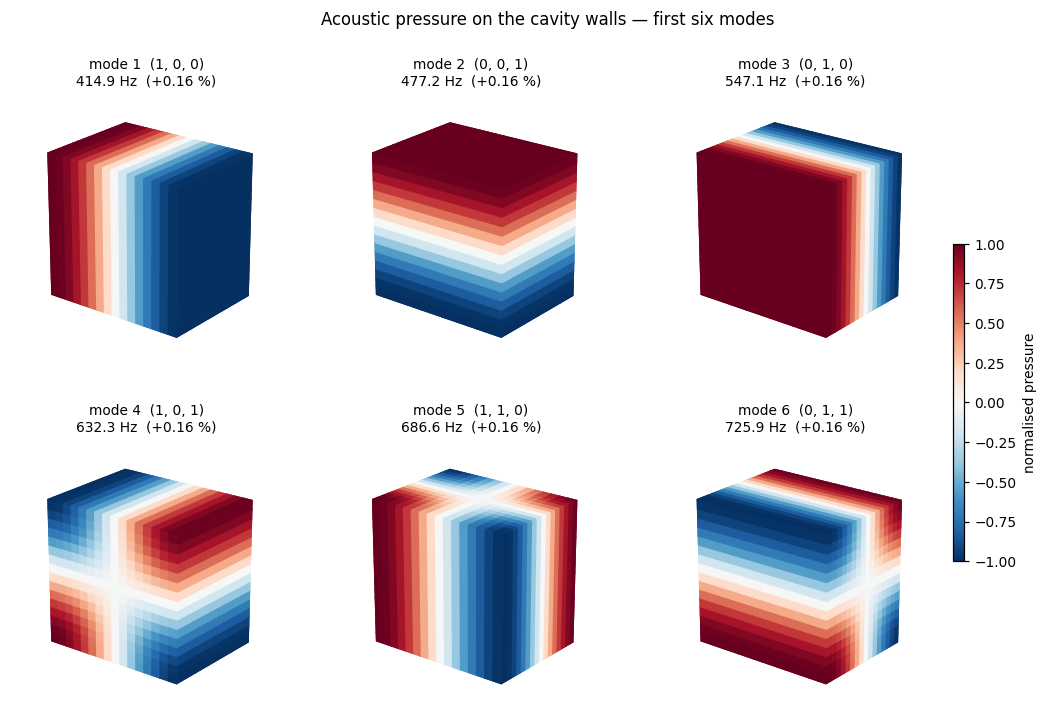

In [3]:
# Gmsh numbers the nodes its own way, so the structured grid is recovered
# from the coordinates: GRID[i, j, k] is the node at (x_i, y_j, z_k).
xs, ix = np.unique(np.round(nodes[:, 0], 9), return_inverse=True)
ys, iy = np.unique(np.round(nodes[:, 1], 9), return_inverse=True)
zs, iz = np.unique(np.round(nodes[:, 2], 9), return_inverse=True)
GRID = np.empty((xs.size, ys.size, zs.size), dtype=int)
GRID[ix, iy, iz] = np.arange(nodes.shape[0])


def plot_cavity_mode(ax, p, title, cmap="RdBu_r"):
    '''Cavity walls coloured by the nodal pressure field.'''
    P = p[GRID]
    P = P / np.abs(P).max()
    if P.ravel()[np.abs(P).argmax()] < 0:
        P = -P
    x, y, z = xs, ys, zs
    norm = plt.Normalize(-1, 1)
    colors = plt.get_cmap(cmap)

    Y, Z = np.meshgrid(y, z, indexing="ij")
    for i, xv in ((0, x[0]), (NX, x[-1])):
        ax.plot_surface(np.full_like(Y, xv), Y, Z, rstride=1, cstride=1,
                        facecolors=colors(norm(P[i])), shade=False)
    X, Z = np.meshgrid(x, z, indexing="ij")
    for j, yv in ((0, y[0]), (NY, y[-1])):
        ax.plot_surface(X, np.full_like(X, yv), Z, rstride=1, cstride=1,
                        facecolors=colors(norm(P[:, j])), shade=False)
    X, Y = np.meshgrid(x, y, indexing="ij")
    for k, zv in ((0, z[0]), (NZ, z[-1])):
        ax.plot_surface(X, Y, np.full_like(X, zv), rstride=1, cstride=1,
                        facecolors=colors(norm(P[:, :, k])), shade=False)

    ax.set_box_aspect((LX, LY, LZ))
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()
    ax.view_init(elev=22, azim=-52)

fig = plt.figure(figsize=(13, 7.5))
for i in range(6):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    plot_cavity_mode(ax, modes[:, i],
                     f"mode {i+1}  {labels[i]}\n{freqs[i]:.1f} Hz  "
                     f"({error[i]:+.2f} %)")
fig.suptitle("Acoustic pressure on the cavity walls — first six modes", y=0.97)
fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"),
             ax=fig.axes, shrink=0.5, aspect=30, pad=0.02,
             label="normalised pressure")
plt.show()

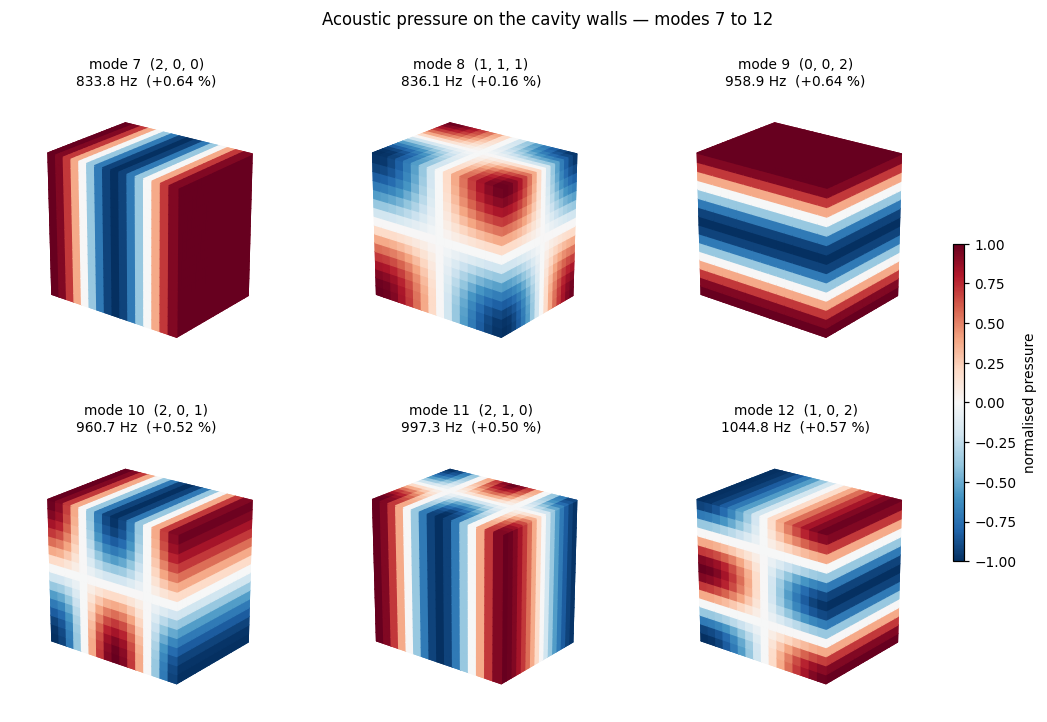

In [4]:
fig = plt.figure(figsize=(13, 7.5))
for i in range(6, 12):
    ax = fig.add_subplot(2, 3, i - 5, projection="3d")
    plot_cavity_mode(ax, modes[:, i],
                     f"mode {i+1}  {labels[i]}\n{freqs[i]:.1f} Hz  "
                     f"({error[i]:+.2f} %)")
fig.suptitle("Acoustic pressure on the cavity walls — modes 7 to 12", y=0.97)
fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"),
             ax=fig.axes, shrink=0.5, aspect=30, pad=0.02,
             label="normalised pressure")
plt.show()

---
## Summary

Air-filled rigid cavity 0.414 × 0.314 × 0.360 m, 16 × 16 × 16 CHEXA8
(4913 pressure DOFs): the first twelve modes are reproduced with a **mean error
of 0.3 %** and a **maximum of 0.65 %** against the closed-form solution, with
every mode shape matching its analytical $(l,m,n)$ pattern.

The deviation is the numerical dispersion of a trilinear element and it is
always positive — the discretised cavity is slightly stiffer than the
continuum. It scales with the square of the mesh size, so it shrinks by a
factor of four every time the mesh is halved.